In [2]:
import xarray as xr
import numpy as np
import functions
import glob as glob

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings('ignore')

In [3]:
rpath = '/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/feedback_input/'

In [4]:
files = glob.glob(rpath+'interval30/tas_piClim*.nc')
files.sort()
ds_tas_piClim = xr.open_mfdataset(files)
ds_tas_2xCO2 = xr.open_dataset(rpath+'tas_abrupt-2xCO2_1920-01-01_2069-12-31.nc')
ds_tas_4xCO2 = xr.open_dataset(rpath+'tas_abrupt-4xCO2_1920-01-01_2069-12-31.nc')

ds_tas = xr.concat([ds_tas_piClim, ds_tas_2xCO2, ds_tas_4xCO2], dim='co2_conc')
ds_tas = ds_tas.assign_coords({'co2_conc':['piClim', '2xCO2', '4xCO2']})

In [5]:
ds_tas_global = functions.computeWeightedMean(ds_tas)
ds_tas_Arctic = functions.computeWeightedMean(ds_tas.sel(lat=slice(60,90)))


# Get land mask

landmask = xr.open_dataset('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/data/other_cloud_vars/LANDFRAC_piClim.nc')
landmask = landmask['LANDFRAC'].isel(time=0)

ds_tas_Arctic_land = functions.computeWeightedMeanMasked(ds_tas.sel(lat=slice(60, 90),lon=slice(0,300)), landmask.sel(lat=slice(60, 90),lon=slice(0,300)))

In [6]:
ds_tas_global_annual = ds_tas_global.groupby('time.year').mean('time')
piClim_mean_global_annual = ds_tas_global_annual['tas'].sel(co2_conc='piClim').mean('year')

ds_tas_Arctic_annual = ds_tas_Arctic.groupby('time.year').mean('time')
piClim_mean_Arctic_annual = ds_tas_Arctic_annual['tas'].sel(co2_conc='piClim').mean('year')

ds_tas_Arctic_JJA = ds_tas_Arctic.sel(time = ds_tas_Arctic['time.month'].isin([6, 7, 8]))
ds_tas_Arctic_JJA = ds_tas_Arctic_JJA.groupby(ds_tas_Arctic_JJA['time.year']).mean('time')
piClim_mean_Arctic_JJA = ds_tas_Arctic_JJA['tas'].sel(co2_conc='piClim').mean('year')

ds_tas_Arctic_SONDJFMAM = ds_tas_Arctic.sel(time = ds_tas_Arctic['time.month'].isin([1, 2, 3, 4, 5, 9, 10, 11, 12]))
ds_tas_Arctic_SONDJFMAM = ds_tas_Arctic_SONDJFMAM.groupby(ds_tas_Arctic_SONDJFMAM['time.year']).mean('time')
piClim_mean_Arctic_SONDJFMAM = ds_tas_Arctic_SONDJFMAM['tas'].sel(co2_conc='piClim').mean('year')

ds_tas_Arctic_land_JJA = ds_tas_Arctic_land.sel(time = ds_tas_Arctic_land['time.month'].isin([6, 7, 8]))
ds_tas_Arctic_land_JJA = ds_tas_Arctic_land_JJA.groupby(ds_tas_Arctic_land_JJA['time.year']).mean('time')
piClim_mean_Arctic_land_JJA = ds_tas_Arctic_land_JJA['tas'].sel(co2_conc='piClim').mean('year')


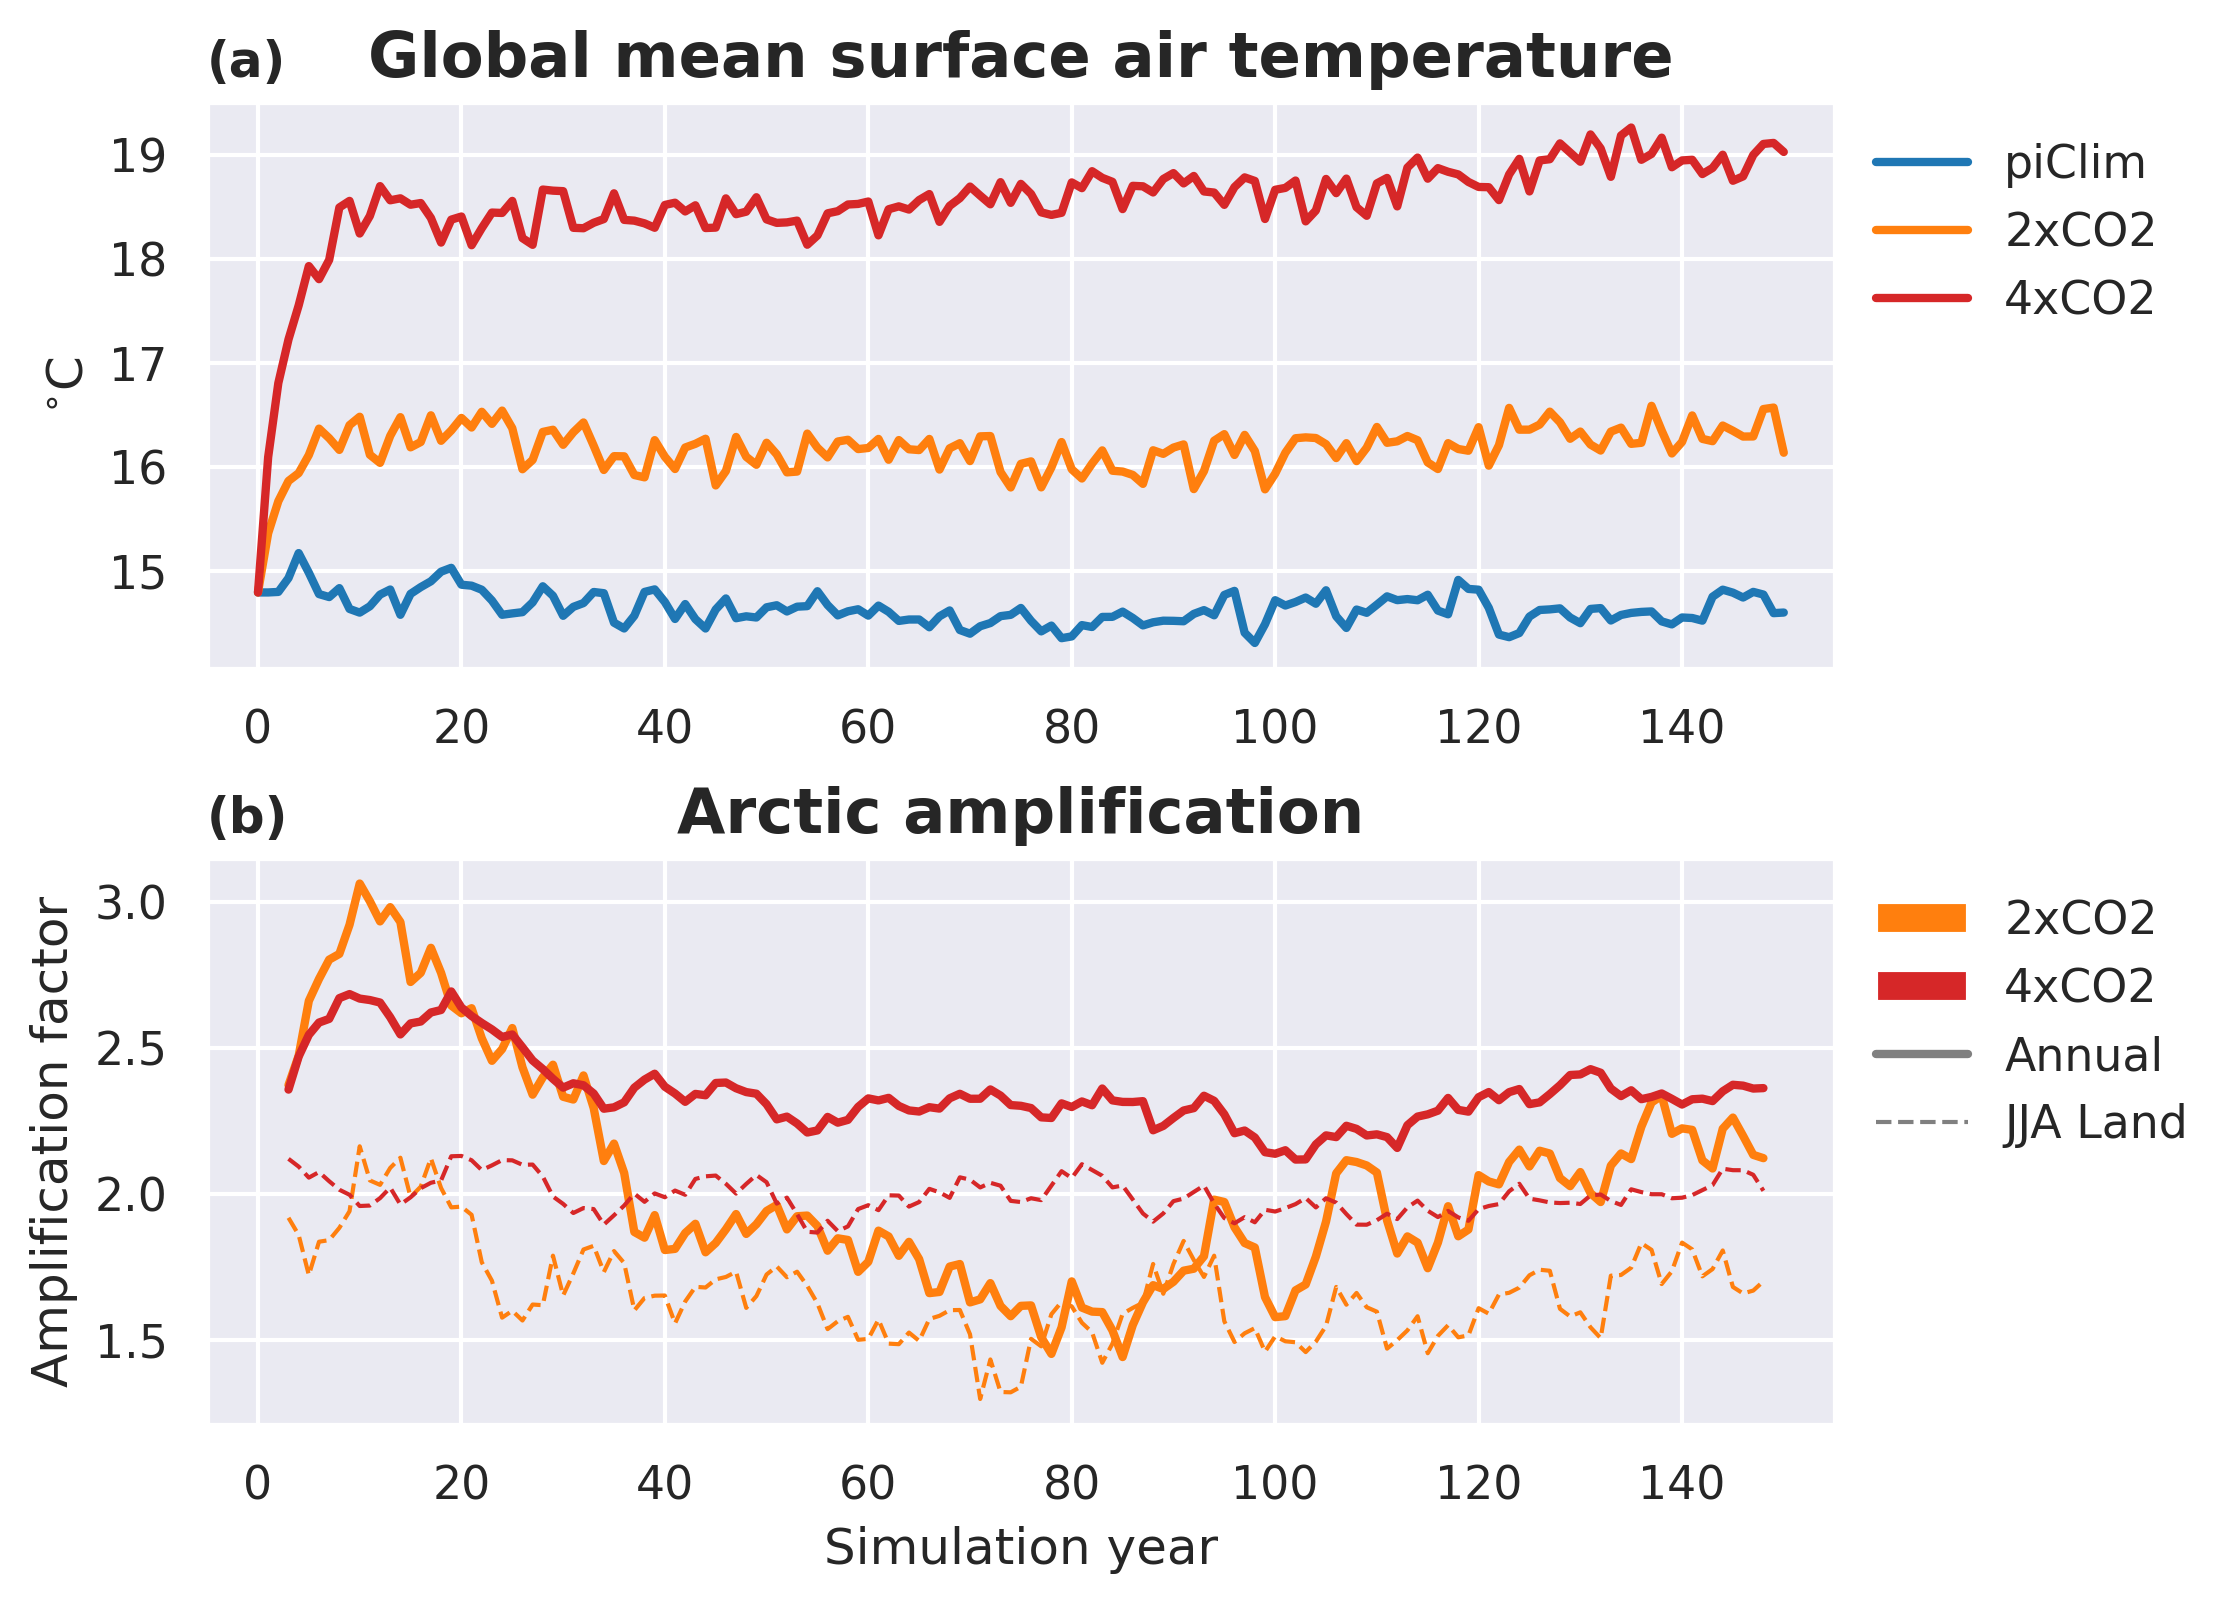

In [8]:
sns.set_theme()
lw=2
window = 5


# Define figure
labels = [['(a)'], ['(b)']]
fig, axs = plt.subplot_mosaic(mosaic=labels, figsize=(7, 6),dpi=300, constrained_layout=True)

# Define top axis
ax1 = axs['(a)']
ax2 = axs['(b)']

# Plot global temperature
start_T = ds_tas_global_annual['tas'].sel(co2_conc='piClim').isel(year=0)-273.15
ax1.plot(np.arange(151), [start_T]+list(ds_tas_global_annual['tas'].sel(co2_conc='piClim')-273.15), lw=lw, label='piClim', color='tab:blue')
ax1.plot(np.arange(151), [start_T]+list(ds_tas_global_annual['tas'].sel(co2_conc='2xCO2')-273.15), lw=lw, label='2xCO2', color='tab:orange')
ax1.plot(np.arange(151), [start_T]+list(ds_tas_global_annual['tas'].sel(co2_conc='4xCO2')-273.15), lw=lw, label='4xCO2', color='tab:red')
ax1.set_title('Global mean surface air temperature', fontweight='bold', fontsize=15)
ax1.set_ylabel('$^{\circ}$C')
ax1.set_xlim([-5, 155])
box = ax1.get_position()
ax1.set_position([box.x0, box.y0 + box.height * 0.1,
                box.width, box.height * 0.9])
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1.0), frameon=False)

# Plot Arctic amplification factor

AA_2xCO2 = (ds_tas_Arctic_annual['tas'].sel(co2_conc='2xCO2')-piClim_mean_Arctic_annual)/(ds_tas_global_annual['tas'].sel(co2_conc='2xCO2')-piClim_mean_global_annual)
AA_4xCO2 = (ds_tas_Arctic_annual['tas'].sel(co2_conc='4xCO2')-piClim_mean_Arctic_annual)/(ds_tas_global_annual['tas'].sel(co2_conc='4xCO2')-piClim_mean_global_annual)

AA_JJA_land_2xCO2 = (ds_tas_Arctic_land_JJA['tas'].sel(co2_conc='2xCO2')-piClim_mean_Arctic_land_JJA)/(ds_tas_global_annual['tas'].sel(co2_conc='2xCO2')-piClim_mean_global_annual)
AA_JJA_land_4xCO2 = (ds_tas_Arctic_land_JJA['tas'].sel(co2_conc='4xCO2')-piClim_mean_Arctic_land_JJA)/(ds_tas_global_annual['tas'].sel(co2_conc='4xCO2')-piClim_mean_global_annual)

ax2.plot(np.arange(151), functions.moving_average(AA_2xCO2.values, window=window, fillNaNextra=True), lw=lw, label='2xCO2', color='tab:orange')
ax2.plot(np.arange(151), functions.moving_average(AA_4xCO2.values, window=window, fillNaNextra=True), lw=lw, label='4xCO2', color='tab:red')

ax2.plot(np.arange(151), functions.moving_average(AA_JJA_land_2xCO2.values, window=window, fillNaNextra=True), lw=lw-1, ls='--', color='tab:orange')
ax2.plot(np.arange(151), functions.moving_average(AA_JJA_land_4xCO2.values, window=window, fillNaNextra=True), lw=lw-1, ls ='--', color='tab:red')

ax2.set_xlim([-5, 155])
ax2.set_xlabel('Simulation year')
ax2.set_title('Arctic amplification', fontweight='bold', fontsize=15)
ax2.set_ylabel('Amplification factor')
box = ax2.get_position()
ax2.set_position([box.x0, box.y0 + box.height * 0.1,
                box.width, box.height * 0.9])

legend_elements =  [Patch(facecolor='tab:orange', edgecolor=None,label='2xCO2'),
                    Patch(facecolor='tab:red', edgecolor=None, label='4xCO2'),
                    Line2D([0], [0], color='grey', lw=lw, linestyle='-', label='Annual'),
                    Line2D([0], [0], color='grey', lw=lw-1, linestyle='--', label='JJA Land')]

ax2.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1.0),frameon=False)

# Label subplots
for label, ax in axs.items():
    ax.set_title(label, loc='left', fontsize=12,fontweight='bold')

fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA1.png',bbox_inches='tight')
fig.savefig('/nird/datapeak/NS9600K/astridbg/arctic-cld-feedbacks/arctic-cloud-feedbacks/article_figs/FigA1.pdf',bbox_inches='tight')
